:::{admonition} Download
:class: important

Download this notebook: **{nb-download}`plot_07_glm_pytree.ipynb`**!

:::

In [1]:
%matplotlib inline
import warnings

warnings.filterwarnings(
    "ignore",
    message="plotting functions contained within `_documentation_utils` are intended for nemos's documentation.",
    category=UserWarning,
)
warnings.filterwarnings(
    "ignore",
    message="Ignoring cached namespace 'core'",
    category=UserWarning,
)

(pytrees_background)=
# JAX Pytrees for Structuring Multiple Predictors

This page introduces JAX pytrees and explains why they are a natural way to organize
inputs and parameters in NeMoS. Through an example, we will demonstrate that structuring your predictors as  pytrees can improve code readability and simplify coefficient handling.

## What is a pytree?

In JAX, a **pytree** is any nested container of arrays: a Python `dict`, `list`, `tuple`,
`NamedTuple`, an [Equinox](https://docs.kidger.site/equinox/) module, or any combination
thereof. The arrays at the deepest level of the nesting are the *leaves*; the containers
holding them are the *nodes*. See the [JAX pytree documentation](https://jax.readthedocs.io/en/latest/pytrees.html)
for the full definition.

What makes pytrees useful is that JAX functions are *pytree-aware*.
[`jax.tree_util.tree_map`](https://jax.readthedocs.io/en/latest/_autosummary/jax.tree_util.tree_map.html)
applies a function to every leaf while preserving the container structure:

In [2]:
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np

data = {"position": jnp.ones(5), "speed": jnp.ones(6)}
jax.tree_util.tree_map(jnp.sum, data)

{'position': Array(5., dtype=float32), 'speed': Array(6., dtype=float32)}

The output is a `dict` with the same keys — the structure is preserved.
The same applies to lists, tuples, or any nesting thereof.

## Structuring model design & coefficients

When fitting a GLM with multiple predictors, the standard approach is to concatenate all
features into a single design matrix — the only input format accepted by most Python
packages, including `scikit-learn`. This works, but requires careful bookkeeping: one
must track which column indices correspond to which predictor and apply the same tedious
indexing when interpreting the fitted coefficients.

NeMoS supports this format too, but also accepts any JAX pytree as input. Organizing
features into a named container — a `dict`, for instance — lets the model return
coefficients in exactly the same structure, so feature names are preserved from input
all the way to the fitted parameters.

### Synthetic data example

In [3]:
# Simulate behavioral variables and spike counts.
# Expand this cell to inspect the data-generating process.
np.random.seed(42)
T = 1000

pos   = np.cumsum(np.random.randn(T) * 0.3)               # 1D random walk
speed = np.abs(np.diff(pos, prepend=pos[0]))               # absolute displacement
hd    = np.cumsum(np.random.randn(T) * 0.2)               # angular random walk
hd    = (hd + np.pi) % (2 * np.pi) - np.pi               # wrap to [-π, π]

# True tuning: Gaussian place field + cosine HD tuning; speed has no effect.
def _bin(x, n):
    edges = np.linspace(x.min(), x.max(), n + 1)[1:-1]
    return np.eye(n)[np.digitize(x, edges)]

n_pos, n_spd, n_hd = 10, 6, 8
pos_centers = np.linspace(pos.min(), pos.max(), n_pos)
true_pos    = np.exp(-0.5 * ((pos_centers - pos.mean()) / (0.3 * pos.std())) ** 2)
hd_centers  = np.linspace(-np.pi, np.pi, n_hd, endpoint=False)
true_hd     = np.cos(hd_centers)

log_rate = _bin(pos, n_pos) @ true_pos + _bin(hd, n_hd) @ true_hd - 1.0
counts   = np.random.poisson(np.exp(log_rate))

The hidden cell above simulates four variables for a foraging animal — position (`pos`), speed (`speed`), head direction (`hd`), and spike counts (`counts`):

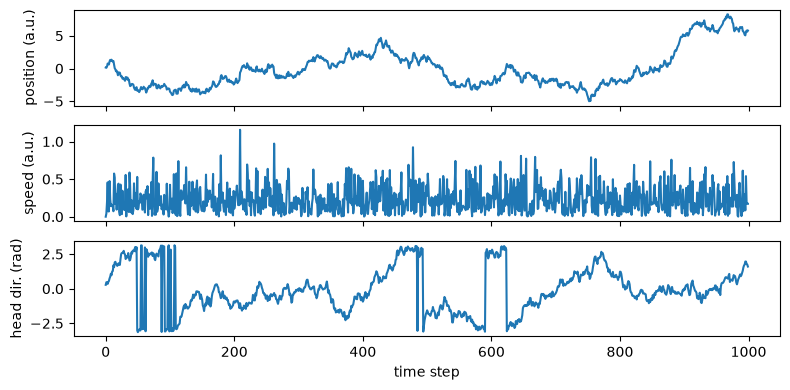

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(8, 4), sharex=True)
axes[0].plot(pos);    axes[0].set_ylabel("position (a.u.)")
axes[1].plot(speed);  axes[1].set_ylabel("speed (a.u.)")
axes[2].plot(hd);     axes[2].set_ylabel("head dir. (rad)")
axes[2].set_xlabel("time step")
fig.tight_layout()

### Fitting GLMs with structured design matrices

We start by constructing a design matrix per task variable, following a common approach: bin each variable and use the bin identity to predict the firing rate at each position, speed, or head direction. See the admonition below for more sophisticated approaches using NeMoS basis functions.

In [5]:
import nemos as nmo

def bin_variable(x, n_bins):
    """One-hot encode a continuous variable into n_bins equal-width bins."""
    edges = np.linspace(x.min(), x.max(), n_bins + 1)[1:-1]
    return np.eye(n_bins)[np.digitize(x, edges)]

X_pos = bin_variable(pos,   n_pos)   # (T, 10)
X_spd = bin_variable(speed, n_spd)   # (T,  6)
X_hd  = bin_variable(hd,    n_hd)    # (T,  8)

:::{admonition} Basis functions vs. binning
:class: note
Binning treats each bin independently, yielding non-smooth estimates that require many bins
for adequate resolution. [Basis functions](table_basis) provide smoother estimates
with fewer parameters and handle circularity properly
(e.g. [`CyclicBSplineEval`](nemos.basis.CyclicBSplineEval) for head direction).
For real analyses we recommend basis functions over binning.
:::

The standard way to proceed from here would be to concatenate `X_pos`, `X_spd` and `X_hd` into a single design matrix of shape `(T, 24)`. The resulting fit produces a coefficient array of shape `(24,)`, and recovering the contribution of each predictor requires knowing which columns map to which variable — in our case, columns 0–9 for position, 10–15 for speed, and 16–23 for head direction.

We can avoid this bookkeeping entirely by assembling the features in a `dict` and fitting the GLM:

In [6]:
X_dict = {"position": X_pos, "speed": X_spd, "head_direction": X_hd}

model = nmo.glm.GLM(regularizer="Ridge", regularizer_strength=0.001)
model.fit(X_dict, counts)
model

,observation_model,PoissonObservations()
,inverse_link_function,<function exp...x7fa5a5d6d080>
,regularizer,Ridge()
,regularizer_strength,0.001
,fix_params,"(None, ...)"
,solver_name,'Newton'
,solver_kwargs,{}
,fit_intercept,True
Name,Type,Value
aux_,NoneType,None
coef_,dict,"{'he...on': Array([-1.112...dtype=float32), 'po...on': Array([-0.251...dtype=float32), 'speed': Array([-0.100...dtype=float32)}"


The coefficients are stored in a dict with exactly the same keys as the input — feature names are
preserved all the way to the fitted parameters.

In [7]:
print(type(model.coef_))
print({k: v.shape for k, v in model.coef_.items()})

<class 'dict'>
{'head_direction': (8,), 'position': (10,), 'speed': (6,)}


The same pattern holds for any other container type. Passing a list, for example, yields a list of coefficient arrays:

In [8]:
model_list = nmo.glm.GLM(regularizer="Ridge", regularizer_strength=0.001)
model_list.fit([X_pos, X_spd, X_hd], counts)

print(type(model_list.coef_))
print("position coefs match:", jnp.allclose(model_list.coef_[0], model.coef_["position"]))

<class 'list'>
position coefs match: False


### Additional benefits: simplified group-wise regularization

Beyond bookkeeping, the pytree structure simplifies two regularization strategies:

- **[Fine-grained regularization](finegrained_regularization)** — regularization strength
  can itself be a pytree matching the structure of the design matrix, allowing different
  penalties per leaf or even per individual parameter. In our example, the design matrix is
  a dict, so we can pass a matching dict of strengths:
  `GLM(regularizer="Ridge", regularizer_strength={"position": 0.1, "speed": 1., "head_direction": 10.})`
  assigns a different regularization level to each task variable.
- **[Group Lasso](variable_selection_group_lasso)** — by default, each leaf of the design
  matrix pytree is treated as a separate group that can be shrunk entirely to zero. In our
  example the leaves are the feature matrices for each task variable (`position`, `speed`,
  `head_direction`), so a `GroupLasso` GLM will automatically group coefficients by task
  variable without any additional configuration.